In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Loading the Dataset
train = pd.read_csv("/kaggle/input/competitions/birdclef-2026/train.csv")
taxonomy = pd.read_csv('/kaggle/input/competitions/birdclef-2026/taxonomy.csv')

print(f"Train Shape: {train.shape}")
print(f'\nColumns: {train.columns.tolist()}')
print(f'\nSpecies Count: {train['primary_label'].nunique()}')
print(f'\nClass Distribution:\n{taxonomy['class_name'].value_counts()}')

Train Shape: (35549, 15)

Columns: ['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']

Species Count: 206

Class Distribution:
class_name
Aves        162
Amphibia     35
Insecta      28
Mammalia      8
Reptilia      1
Name: count, dtype: int64


In [4]:
# Basic Stats
print(f'Total Recordings: {len(train)}')
print(f'\nRating Distribution: \n{train['rating'].value_counts().sort_index()}')
print(f'\nCollection Distribution: \n{train['collection'].value_counts()}')
print(f'\nTop 10 species by recordings: \n{train['primary_label'].value_counts().head(10)}')

Total Recordings: 35549

Rating Distribution: 
rating
0.0    12849
0.5       22
1.0      147
1.5      120
2.0      598
2.5      518
3.0     2738
3.5     1509
4.0     8018
4.5     2185
5.0     6845
Name: count, dtype: int64

Collection Distribution: 
collection
XC      23043
iNat    12506
Name: count, dtype: int64

Top 10 species by recordings: 
primary_label
rubthr1    499
banana     498
fepowl     497
soulap1    497
houspa     496
coffal1    495
osprey     495
socfly1    494
compau     493
yeofly1    493
Name: count, dtype: int64


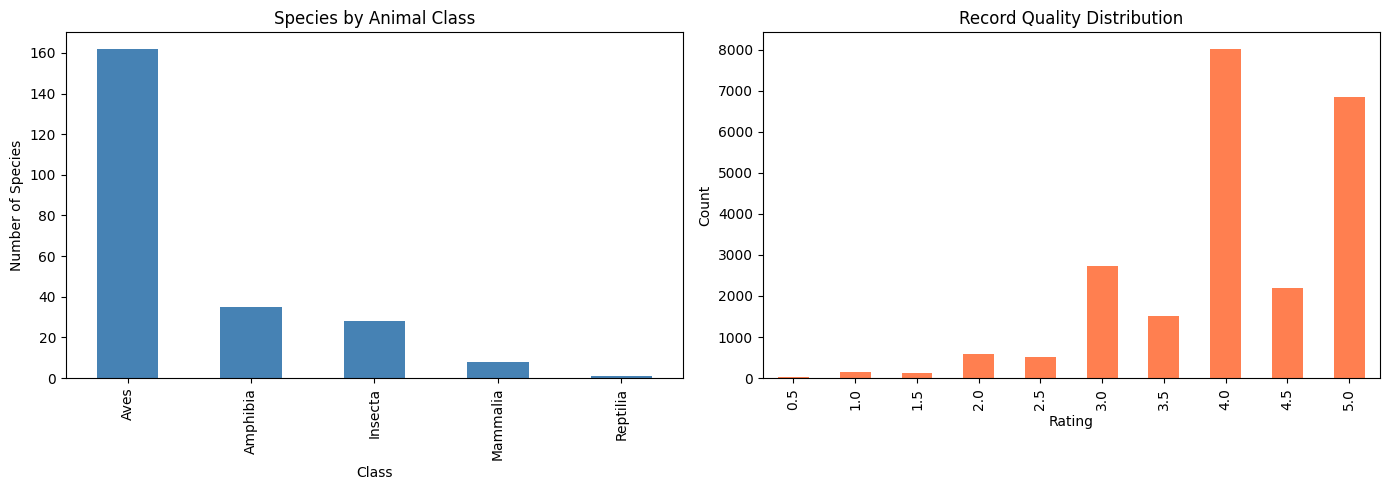

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Class Distribution
taxonomy['class_name'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Species by Animal Class')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Species')

# Rating Distribution
train[train['rating'] > 0]['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Record Quality Distribution')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

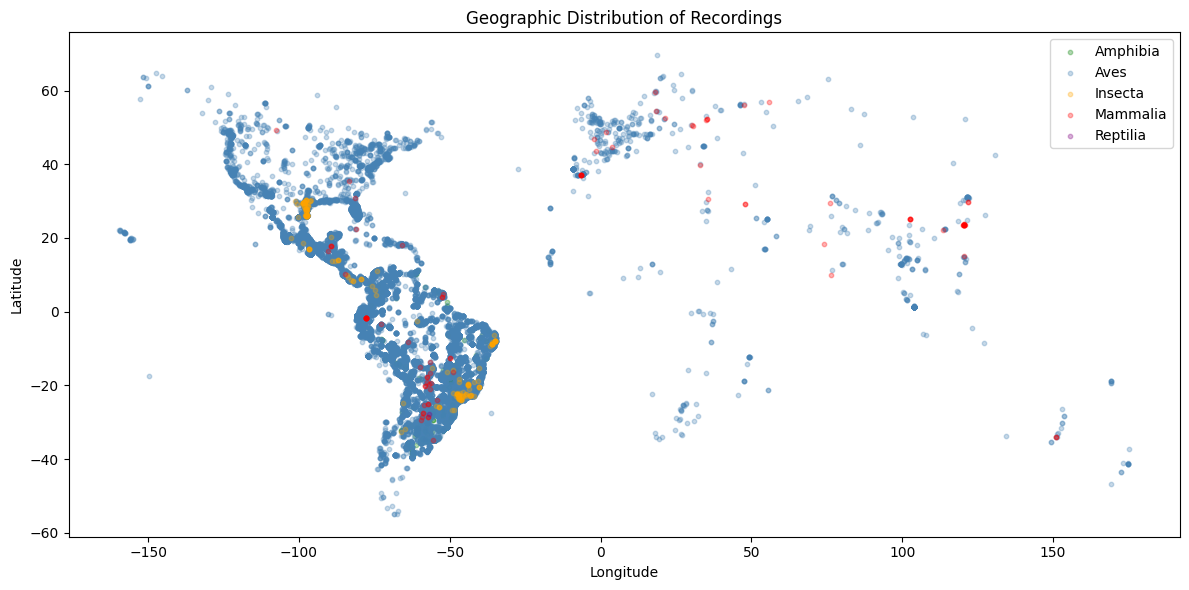

In [6]:
# Geographic Distribution
fig, ax = plt.subplots(figsize=(12, 6))

# Plot by class
colors = {'Aves': 'steelblue', 'Amphibia': 'green', 
          'Insecta': 'orange', 'Mammalia': 'red', 'Reptilia': 'purple'}

for class_name, group in train.groupby('class_name'):
    ax.scatter(group['longitude'], group['latitude'], 
               label=class_name, 
               color=colors[class_name],
               alpha=0.3, s=10)

ax.set_title('Geographic Distribution of Recordings')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
plt.tight_layout()
plt.show()

Recordings come from worldwide but heavily concentrated in South America — makes sense since Pantanal is in Brazil! The test data will be from this region specifically

In [7]:
# Audio Visualization
import librosa
import librosa.display
import os

# Loading one audio file
sample_file = train['filename'].iloc[0]
audio_path = f'/kaggle/input/competitions/birdclef-2026/train_audio/{sample_file}'

y, sr = librosa.load(audio_path, duration=10)

print(f"Species: {train['primary_label'].iloc[0]}")
print(f"Common name: {train['common_name'].iloc[0]}")
print(f"Sample rate: {sr} Hz")
print(f"Duration: {len(y)/sr:.1f} seconds")

Species: 1161364
Common name: Guyalna cuta
Sample rate: 22050 Hz
Duration: 10.0 seconds


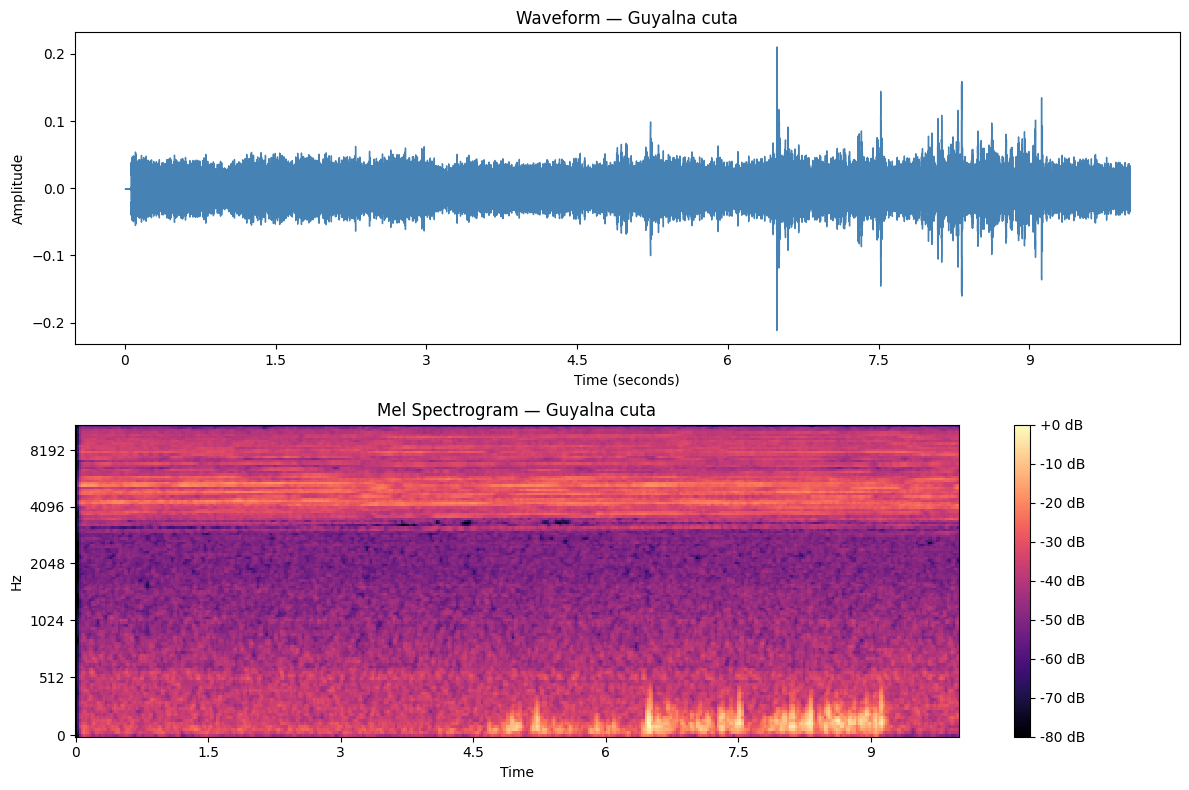

In [10]:
# Waveform + Mel Spectogram
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Waveform
librosa.display.waveshow(y, sr=sr, ax=axes[0], color='steelblue')
axes[0].set_title('Waveform — Guyalna cuta')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Amplitude')

# Mel Spectrogram
mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[1])
axes[1].set_title('Mel Spectrogram — Guyalna cuta')
plt.colorbar(axes[1].collections[0], ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

Guyalna cuta is a low frequency caller — probably an amphibian/frog! Frogs call in low frequencies 🐸

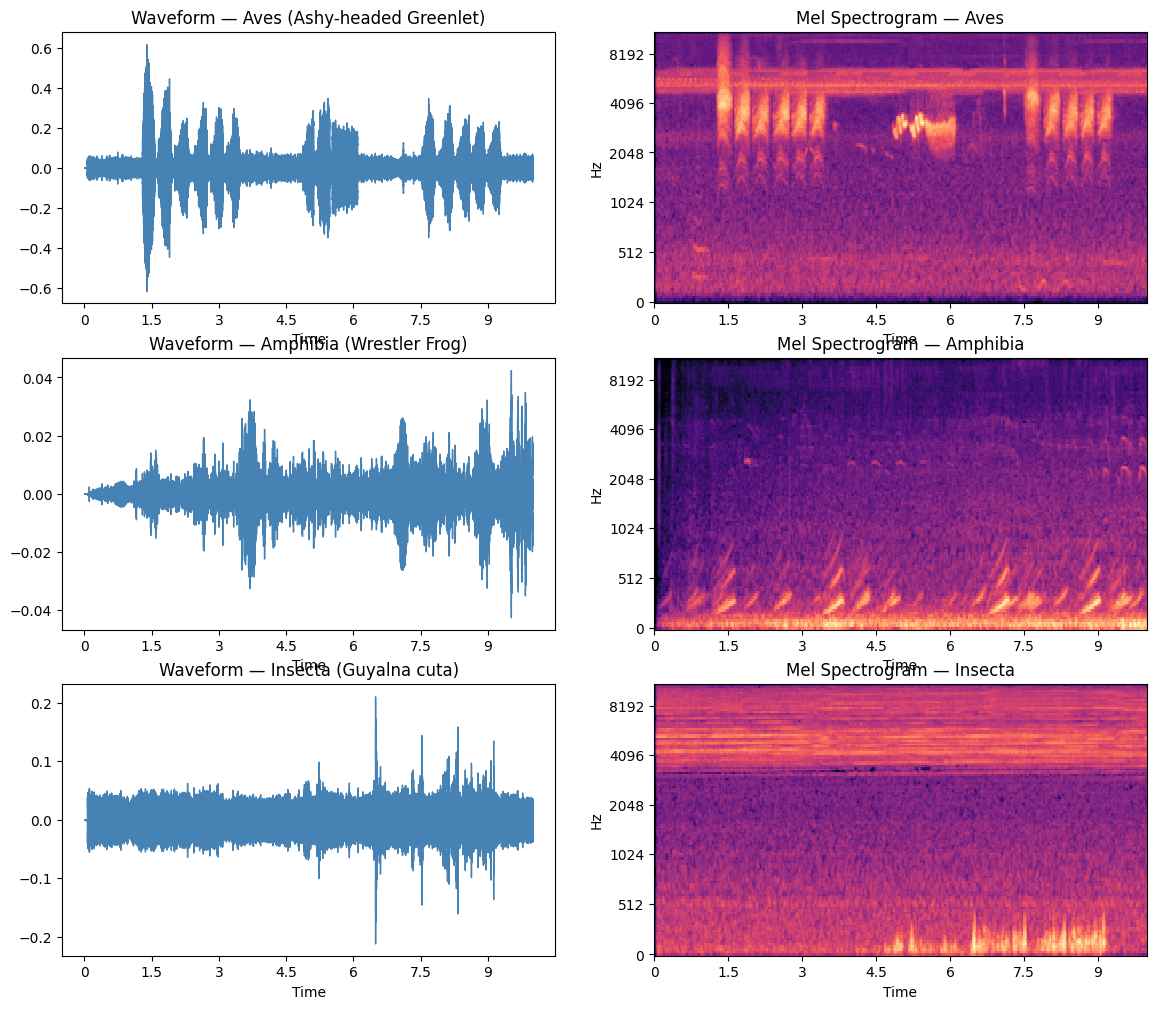

In [11]:
# Compare spectrograms of 3 different species
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Pick 3 different classes
classes_to_show = ['Aves', 'Amphibia', 'Insecta']

for idx, class_name in enumerate(classes_to_show):
    # Get a sample from this class
    sample = train[train['class_name'] == class_name].iloc[0]
    audio_path = f'/kaggle/input/competitions/birdclef-2026/train_audio/{sample["filename"]}'
    
    # Load audio
    y_sample, sr_sample = librosa.load(audio_path, duration=10)
    
    # Waveform
    librosa.display.waveshow(y_sample, sr=sr_sample, 
                             ax=axes[idx][0], color='steelblue')
    axes[idx][0].set_title(f'Waveform — {class_name} ({sample["common_name"]})')
    
    # Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=y_sample, sr=sr_sample, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=sr_sample,
                             x_axis='time', y_axis='mel', ax=axes[idx][1])
    axes[idx][1].set_title(f'Mel Spectrogram — {class_name}')

**Aves:**   
Waveform    → sharp distinct bursts, clear pattern  
Spectrogram → bright vertical stripes at high frequency (2048-8192 Hz)  
            → birds sing in HIGH frequencies!  

**Amphibia:**  
Waveform    → repetitive rhythmic pattern  
Spectrogram → activity concentrated at BOTTOM (0-512 Hz)  
            → frogs call in LOW frequencies!    

**Insecta:**  
Waveform    → continuous noisy signal  
Spectrogram → broad red band across ALL frequencies  
            → insects make broadband noise!  

Bird      → high frequency spikes  
Frog      → low frequency rhythmic  
Insect    → broadband continuous

In [12]:
# Key Insights Summary
print("=" * 50)
print("KEY INSIGHTS — BirdCLEF+ 2026")
print("=" * 50)

print(f"""
DATASET:
→ {len(train):,} total recordings
→ {train['primary_label'].nunique()} species to classify
→ {taxonomy['class_name'].nunique()} animal classes

CLASS BREAKDOWN:
→ Birds (Aves)      : 162 species (78%) — dominant!
→ Frogs (Amphibia)  : 35 species  (17%)
→ Insects (Insecta) : 28 species  (14%)
→ Mammals           : 8 species   (4%)
→ Reptiles          : 1 species   (0.5%)

DATA QUALITY:
→ {len(train[train['rating']==0]):,} unrated recordings (36%)
→ {len(train[train['rating']>=4]):,} high quality recordings (rating 4+)

COLLECTIONS:
→ Xeno-canto (XC)   : {len(train[train['collection']=='XC']):,} recordings
→ iNaturalist (iNat): {len(train[train['collection']=='iNat']):,} recordings

AUDIO INSIGHTS:
→ Birds call at HIGH frequencies  (2000-8000 Hz)
→ Frogs call at LOW frequencies   (0-512 Hz)
→ Insects produce BROADBAND noise (all frequencies)
→ Each species has unique spectrogram fingerprint!

MODELING APPROACH:
→ Convert audio → Mel Spectrogram → Image
→ Train CNN to classify spectrograms
→ 234 species predictions per 5-second segment
""")


KEY INSIGHTS — BirdCLEF+ 2026

DATASET:
→ 35,549 total recordings
→ 206 species to classify
→ 5 animal classes

CLASS BREAKDOWN:
→ Birds (Aves)      : 162 species (78%) — dominant!
→ Frogs (Amphibia)  : 35 species  (17%)
→ Insects (Insecta) : 28 species  (14%)
→ Mammals           : 8 species   (4%)
→ Reptiles          : 1 species   (0.5%)

DATA QUALITY:
→ 12,849 unrated recordings (36%)
→ 17,048 high quality recordings (rating 4+)

COLLECTIONS:
→ Xeno-canto (XC)   : 23,043 recordings
→ iNaturalist (iNat): 12,506 recordings

AUDIO INSIGHTS:
→ Birds call at HIGH frequencies  (2000-8000 Hz)
→ Frogs call at LOW frequencies   (0-512 Hz)
→ Insects produce BROADBAND noise (all frequencies)
→ Each species has unique spectrogram fingerprint!

MODELING APPROACH:
→ Convert audio → Mel Spectrogram → Image
→ Train CNN to classify spectrograms
→ 234 species predictions per 5-second segment

